In [1]:
import ast
import numpy as np
import pandas as pd

<div dir="rtl"> 
שלב 1: בניית פונקציה prepare_date()

In [2]:
#עמודות Data Leakage
LEAKAGE_COLUMNS = ["averageRating", "numVotes", "BoxOffice"]

In [3]:
#בונים פונקציה שסופרת כמות שחקנים בסרט
def count_actors(actors_raw):
    if pd.isna(actors_raw):
        return 0
    try:
        actors_list = ast.literal_eval(actors_raw)
        return len(actors_list)
    except (ValueError, SyntaxError):
        # במידה והערך בטבלה לא רשימה
        return 0

In [4]:
def clean_genres(genres_raw):
    # ניקיון של סוגריים: ['Drama'] -> Drama. 
    #גם טיפול בערכים שלא עומדים בתנאי של LIST
    if pd.isna(genres_raw):
        return ""
    cleaned = genres_raw.replace("[", "").replace("]", "")
    cleaned = cleaned.replace("'", "").replace('"', "")
    parts = [part.strip() for part in cleaned.split(",")]
    return ",".join(parts)

In [5]:
def prepare_data(df):
    movies_df = df.copy()

    # טיפול בג'אנרים
    movies_df["genres"] = movies_df["genres"].apply(clean_genres)

    # startYear = 0    זה טעות, 0 יגרום למודל לטעות.
    movies_df["startYear"] = movies_df["startYear"].replace(0, np.nan)
    
    #פיטצר חדש: חישוב - כמות ג'אנרים בכל סרט וסרט
    movies_df["num_genres"] = movies_df["genres"].apply(
        lambda g: len(g.split(",")) if g else 0
    )

    # פיטצר חדש: חישוב - ג'אנר ראשי
    movies_df["main_genre"] = movies_df["genres"].apply(
        lambda g: g.split(",")[0] if g else "Unknown"
    )

    # פיטצר חדש: חישוב - באקטינג לפי משך הסרט
    runtime_bins   = [0, 70, 85, 100, 120, 150, 400]
    runtime_labels = [1, 2, 3, 4, 5, 6]
    
    movies_df["runtime_bin"] = pd.cut(
        movies_df["runtimeMinutes"], bins=runtime_bins, labels=runtime_labels
    ).astype("float")

    #פיטצר חדש: יחס משך הסרט / מספר גאנרים בסרט   
    movies_df["runtime_per_genre"] = np.where(
        movies_df["num_genres"] > 0,
        movies_df["runtimeMinutes"] / movies_df["num_genres"],
        np.nan
    )
    #פיטצר חדש: משתמשים בפונקציה שבנינו מקודם ומחשבים כמה שחקנים בכל סרט
    movies_df["num_actors"] = movies_df["lead_actors_ids"].apply(count_actors)
    #פיטצר חדש (בינארי): האם בכלל קיימים שחקנים בסרט
    movies_df["is_no_cast"] = (movies_df["num_actors"] == 0).astype(int)


    #פיטצר חדש: כמה מילים יש בכל סרט
    movies_df["title_word_count"] = (
        movies_df["primaryTitle"].fillna("").apply(lambda t: len(t.split()))
    )

    #פיטצר חדש: האם יש נקודתיים בשם הסרט
    movies_df["title_has_colon"] = (
        movies_df["primaryTitle"].fillna("").str.contains(":").astype(int)
    )
    #פיטצר חדש: האם שפה של סרט הוא אנגלית
    movies_df["is_english"] = (movies_df["Language"] == "English").astype(int)
    #פיטצר חדש - האם סרט נוצר בארצות הברית
    movies_df["is_us"]      = (movies_df["Country"] == "United States").astype(int)

    #פיטצר חדש: האם קיים תקציב עבור כל סרט
    movies_df["has_budget"] = movies_df["budget"].notna().astype(int)

    feature_columns = [
        "startYear", "runtimeMinutes",
        "num_genres", "main_genre",
        "runtime_bin", "runtime_per_genre",
        "num_actors", "is_no_cast",
        "title_word_count", "title_has_colon",
        "is_english", "is_us",
        "has_budget",
    ]
    return movies_df[feature_columns]

<div dir="rtl"> 
בדיקה: האם פונקציה שבנינו עובדת

In [6]:
df = pd.read_csv("dataset.csv", low_memory=False)
data_prepared = prepare_data(df)

In [7]:
data_prepared.sample(5)

,startYear,runtimeMinutes,num_genres,main_genre,runtime_bin,runtime_per_genre,num_actors,is_no_cast,title_word_count,title_has_colon,is_english,is_us,has_budget
120267,1980.0,120.0,1,Action,4.0,120.000000,0,1,2,0,0,0,0
117791,1933.0,77.0,2,Comedy,2.0,38.500000,5,0,4,0,1,0,0
51906,2008.0,82.0,3,Drama,2.0,27.333333,5,0,3,0,1,1,0
132978,2017.0,76.0,2,Documentary,2.0,38.000000,0,1,7,1,0,0,0
87779,2007.0,80.0,1,Documentary,2.0,80.000000,0,1,1,0,0,0,0


<div dir="rtl">
שלב 2: הכנה פיטצרים לפני בניית המודל

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    GridSearchCV, KFold, cross_validate, cross_val_predict
)
from sklearn.metrics import mean_squared_error, mean_absolute_error
import joblib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [9]:
#מוחקים מדאטה שהולך לאמן את המודל ערכים חסרים של משתנה מטרה
df_train = df.dropna(subset=["averageRating"]).copy()
df_train = df_train.reset_index(drop=True)

In [10]:
#בונים X ו Y, דאטה של פיטצרים ועמודה של ערך המטרה
X = prepare_data(df_train)
y = df_train["averageRating"].values

In [11]:
#נוודא גבולות של ערך המטרה
print(f"גודל של דאטה שהולך לאמן את המודל: {X.shape}")
print(f"ערך המטרה — min: {y.min():.1f}, max: {y.max():.1f}, ממוצע: {y.mean():.2f}")

גודל של דאטה שהולך לאמן את המודל: (115560, 13)
ערך המטרה — min: 1.0, max: 10.0, ממוצע: 6.07


In [12]:
#נבדוק כמה ערכים חסרים יש בכל פיטצר
missing = X.isnull().sum()
print("\nערכים חסרים בכל פיטצר:")
print(missing[missing > 0])


ערכים חסרים בכל פיטצר:
startYear               1
runtime_per_genre    1260
dtype: int64


In [13]:
# נחלק פיטצרים לפי קבוצות שלהם וכל קבוצה תקבל טרנספורם שונה
numeric_cols = [
    "startYear", "runtimeMinutes",
    "num_genres", "runtime_bin", "runtime_per_genre",
    "num_actors", "title_word_count"
]
binary_cols      = ["is_no_cast", "title_has_colon", "is_english", "is_us", "has_budget"]
categorical_cols = ["main_genre"]


In [14]:
#פיטצרים נומרים - לערכים חסרים נכניס חציון (לא רגיש לחריגים) וגם ננרמל נתונים
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])

In [15]:
# פיטצרים בינרים - ערכים חסרים נמלא בערך שכיח
binary_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
])

In [16]:
#בפיצטרים קטגוריאלים נכניס במקום ערכים חסרים - ערך שכיח. בנוסף נבצע OneHotEncoder
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

In [17]:
#נבצע לכל סוג של פיטצר טיפול שונה ובסוף נקבל חזרה כדאטה מאוחד
preprocessor = ColumnTransformer(transformers=[
    ("numeric",     numeric_transformer,     numeric_cols),
    ("binary",      binary_transformer,      binary_cols),
    ("categorical", categorical_transformer, categorical_cols),
])

In [18]:
preprocessor

ColumnTransformer(transformers=[('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['startYear', 'runtimeMinutes', 'num_genres',
                                  'runtime_bin', 'runtime_per_genre',
                                  'num_actors', 'title_word_count']),
                                ('binary',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['is_no_cast', 'title_has_colon', 'is_english',
                                  'is_us', 'has_budget']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse_output=False))]),
                                 ['main_genre'])])

In [19]:
#ניצור קרוס ולידציה פנימית בשביל למנוע זליגת נתונים בשלב של חיפוש פרמטרים עבור אלסטיק נט
inner_cv = KFold(n_splits=5, shuffle=True, random_state=42)

<div dir="rtl">
שלב 3: בניית מודל אלסטיק נט

In [20]:
#נכין פייפליין לאלסטיק נט
elastic_net_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", ElasticNet(random_state=42, max_iter=5000)),
])

In [21]:
#נגדיר טווח פרמטרים שעליהם נעשה חיפוש 
param_grid_en = {
    "model__alpha":    [0.01, 0.1, 1.0],
    "model__l1_ratio": [0.1, 0.5, 0.9],
}

In [22]:
# הגדרות לחיפוש פרמטרים טובים ביותר עבור מודל אלסטיק נט
gs_en = GridSearchCV(
    elastic_net_pipeline,
    param_grid_en,
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

In [23]:
#אימון המודל אלסטיק נט
gs_en.fit(X, y)

print(f"\nפרמטרים הכי טובים: {gs_en.best_params_}")
print(f"RMSE של קרוס ולידציה פנימית: {-gs_en.best_score_:.4f}")

best_elastic_net = gs_en.best_estimator_

Fitting 5 folds for each of 9 candidates, totalling 45 fits

פרמטרים הכי טובים: {'model__alpha': 0.01, 'model__l1_ratio': 0.1}
RMSE של קרוס ולידציה פנימית: 1.1609


<div dir="rtl">
שלב 4: בניית מודל ראנדום פורסט

In [24]:
#פייפליין לראנדום פורסט
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42, n_jobs=-1)),
])

In [25]:
#נגדיר פרמטרים לחיפוש
param_grid_rf = {
    #100 או 200 עצים
    "model__n_estimators": [100, 200],
    #עומק העצים
    "model__max_depth":    [10, 20, None],  # None = деревья растут до полного разбиения
}

In [26]:
#הגדרות של החיפוש
gs_rf = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    cv=inner_cv,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1,
)

In [27]:
#אימון מודל ראנדום פורסט
print("Training Random Forest with GridSearchCV (6 combinations × 5 folds)...")
gs_rf.fit(X, y)

print(f"\nפרמטרים הכי טובים: {gs_rf.best_params_}")
print(f"RMSE של קרוס ולידציה פנימית: {-gs_rf.best_score_:.4f}")

best_rf = gs_rf.best_estimator_

Training Random Forest with GridSearchCV (6 combinations × 5 folds)...
Fitting 5 folds for each of 6 candidates, totalling 30 fits

פרמטרים הכי טובים: {'model__max_depth': 10, 'model__n_estimators': 200}
RMSE של קרוס ולידציה פנימית: 1.1333


<div dir="rtl">
שלב 5: הערכת מודלים (אלסטיק נט נגד ראנדום פורסט)

In [33]:
# הפרדנו קרוס שליגציה לחיצוני ופנימי בשביל למנוע זליגת נתונים
outer_cv = KFold(n_splits=10, shuffle=True, random_state=42)

In [34]:
#נגדיר ערכים שאנו רוצים לחשב עבור כל מודל
cv_scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae":  "neg_mean_absolute_error",
    "r2":   "r2",
}

In [35]:
#חישוב מדדים עבור כל מודל
cv_en = cross_validate(best_elastic_net, X, y, cv=outer_cv, scoring=cv_scoring, n_jobs=-1)
cv_rf = cross_validate(best_rf,          X, y, cv=outer_cv, scoring=cv_scoring, n_jobs=-1)

In [36]:
#תצוגה של מדדים שמצאנו
def summarize_cv(cv_result, model_name):
    return {
        "Model":        model_name,
        "RMSE mean":    round(-cv_result["test_rmse"].mean(), 4),
        "RMSE ± std":   round( cv_result["test_rmse"].std(),  4),
        "MAE mean":     round(-cv_result["test_mae"].mean(),  4),
        "MAE ± std":    round( cv_result["test_mae"].std(),   4),
        "R² mean":      round( cv_result["test_r2"].mean(),   4),
        "R² ± std":     round( cv_result["test_r2"].std(),    4),
    }
results_df = pd.DataFrame([
    summarize_cv(cv_en, "Elastic Net"),
    summarize_cv(cv_rf, "Random Forest"),
])
display(results_df)

,Model,RMSE mean,RMSE ± std,MAE mean,MAE ± std,R² mean,R² ± std
0,Elastic Net,1.1608,0.0095,0.8945,0.0068,0.1936,0.0076
1,Random Forest,1.1328,0.0089,0.8668,0.0060,0.2321,0.0070


<div dir="rtl">
שלב 6: ניתוח שגיאות

In [37]:
#בונים חיזוי לכל מודל, תוך הקפדה שהמודל לא לומד סרטים שהוא ראה מקודם
y_pred_en = cross_val_predict(best_elastic_net, X, y, cv=outer_cv, n_jobs=-1)
y_pred_rf = cross_val_predict(best_rf,          X, y, cv=outer_cv, n_jobs=-1)

In [39]:
#נכין דאטהפריים של סרטים שבהם מודלים עשו טעות חזקה ביותר
error_df = pd.DataFrame({
    "title":       df_train["primaryTitle"].values,
    "true_rating": y,
    "pred_en":     y_pred_en,
    "pred_rf":     y_pred_rf,
    # residual > 0: занижение (реальный рейтинг выше предсказания)
    # residual < 0: завышение (реальный рейтинг ниже предсказания)
    "residual_en": y - y_pred_en,
    "residual_rf": y - y_pred_rf,
    "genre":       X["main_genre"].values,
    "year":        X["startYear"].values,
    "is_us":       X["is_us"].values,
    "has_budget":  X["has_budget"].values,
})

In [40]:
#נוסיף לדאטה פריים עמודה של עשור הסרט
def year_to_decade(year):
    if pd.isna(year):
        return "Unknown"
    decade = int(year // 10 * 10)
    return f"{decade}s"

error_df["decade_str"] = error_df["year"].apply(year_to_decade)

In [53]:
# סרטים שבהם ראנדום פורסט נתן חיזוי נמוך ביותר מאשר הדירוג האמיתי
print("\n=== Random Forest: Top 10 Underpredictions (model underrated the movie) ===")

underpred_rf = error_df.nlargest(10, "residual_rf")
underpred_rf = underpred_rf[["title", "true_rating", "pred_rf", "residual_rf", "genre", "year"]]
underpred_rf = underpred_rf.round(2).reset_index(drop=True)
underpred_rf["year"] = underpred_rf["year"].astype(int)
display(underpred_rf)


=== Random Forest: Top 10 Underpredictions (model underrated the movie) ===


,title,true_rating,pred_rf,residual_rf,genre,year
0,Son-nim-1 Cheo-beon-jjae I-ya-gi,9.1,4.26,4.84,Horror,2011
1,Halloween Deluxe,9.1,4.52,4.58,Horror,2019
2,Oscuro by Rene Potter,8.6,4.08,4.52,Horror,2016
3,Under Reflex,9.4,4.97,4.43,Action,2024
4,Prince of Eurasia,9.5,5.17,4.33,Action,2022
5,Puli Vachindi Meka Chachindi,9.5,5.24,4.26,Thriller,2021
6,ODA,9.6,5.38,4.22,Documentary,2020
7,Akkada Varu Ikkada Unnaru,9.1,4.89,4.21,Horror,2024
8,Junkyard,9.2,5.01,4.19,Action,2013
9,Jefa De Jefas,9.2,5.02,4.18,Action,2024


In [52]:
# סרטים שבהם ראנדום פורסט נתן חיזוי גבוה ביותר מאשר הדירוג האמיתי
print("=== Random Forest: Top 10 Overpredictions (model overrated the movie) ===")

overpred_rf = error_df.nsmallest(10, "residual_rf")
overpred_rf = overpred_rf[["title", "true_rating", "pred_rf", "residual_rf", "genre", "year"]]
overpred_rf = overpred_rf.round(2).reset_index(drop=True)
overpred_rf["year"] = overpred_rf["year"].astype(int)
display(overpred_rf)

=== Random Forest: Top 10 Overpredictions (model overrated the movie) ===


,title,true_rating,pred_rf,residual_rf,genre,year
0,At the Back of the Screen,1.5,7.78,-6.28,Documentary,2020
1,Rape of the Soul,1.7,7.83,-6.13,Documentary,2006
2,Justin Bieber: Always Believing,1.0,7.12,-6.12,Documentary,2012
3,Kurz,1.2,7.19,-5.99,Documentary,2023
4,Brush with Life: The Art of Being Edward Biberman,1.5,7.38,-5.88,Documentary,2007
5,Obama in NC: The Path to History,1.5,7.35,-5.85,Documentary,2010
6,Tribalism Is Killing Us,1.3,7.07,-5.77,Documentary,2019
7,Justin Bieber's Believe,1.6,7.31,-5.71,Documentary,2013
8,Justin Bieber: Never Say Never,1.7,7.41,-5.71,Documentary,2011
9,Ramo Trip,1.4,7.08,-5.68,Documentary,2012


In [54]:
# השוואה: כמה מהשגיאות של שני המודלים חופפות
over_en  = set(error_df.nsmallest(10, "residual_en")["title"])
over_rf  = set(error_df.nsmallest(10, "residual_rf")["title"])
under_en = set(error_df.nlargest(10, "residual_en")["title"])
under_rf = set(error_df.nlargest(10, "residual_rf")["title"])

print(f"\nOverprediction overlap (EN vs RF):  {len(over_en & over_rf)}/10")
print(f"Underprediction overlap (EN vs RF): {len(under_en & under_rf)}/10")


Overprediction overlap (EN vs RF):  7/10
Underprediction overlap (EN vs RF): 4/10


<div dir="rtl">
שלב 7: ניתוח הוגנות

In [56]:
# פונקציה שמחשבת RMSE ו-MAE עבור קבוצה אחת של סרטים
def slice_metrics(subset_df, pred_col, slice_name, model_name):
    rmse = np.sqrt(mean_squared_error(subset_df["true_rating"], subset_df[pred_col]))
    mae  = mean_absolute_error(subset_df["true_rating"], subset_df[pred_col])
    return {
        "Slice":  slice_name,
        "Model":  model_name,
        "N":      len(subset_df),
        "RMSE":   round(rmse, 4),
        "MAE":    round(mae, 4),
    }

# שני המודלים שאנחנו רוצים להשוות
models_preds = [("pred_en", "Elastic Net"), ("pred_rf", "Random Forest")]

In [57]:
# חתך 1: לפי ז'אנר (5 הז'אנרים הכי נפוצים)
top5_genres = error_df["genre"].value_counts().head(5).index.tolist()

genre_rows = []
for genre in top5_genres:
    group = error_df[error_df["genre"] == genre]
    for pred_col, model_name in models_preds:
        genre_rows.append(slice_metrics(group, pred_col, genre, model_name))

genre_fairness = pd.DataFrame(genre_rows).sort_values(["Slice", "Model"])
print("=== Fairness by Genre ===")
display(genre_fairness)

=== Fairness by Genre ===


,Slice,Model,N,RMSE,MAE
4,Action,Elastic Net,13987,1.2759,1.0072
5,Action,Random Forest,13987,1.2371,0.9646
2,Comedy,Elastic Net,27975,1.1659,0.9022
3,Comedy,Random Forest,27975,1.1478,0.8828
8,Crime,Elastic Net,6390,1.0468,0.8063
9,Crime,Random Forest,6390,1.0322,0.7885
6,Documentary,Elastic Net,10496,1.0512,0.7780
7,Documentary,Random Forest,10496,1.0155,0.7439
0,Drama,Elastic Net,33564,1.1000,0.8431
1,Drama,Random Forest,33564,1.0719,0.8203


In [59]:
# חתך 2: ארצות הברית מול שאר העולם
us_rows = []
for us_val, label in [(1, "US"), (0, "Non-US")]:
    group = error_df[error_df["is_us"] == us_val]
    for pred_col, model_name in models_preds:
        us_rows.append(slice_metrics(group, pred_col, label, model_name))

us_fairness = pd.DataFrame(us_rows).sort_values(["Slice", "Model"])
print("\n=== Fairness: US vs Non-US ===")
display(us_fairness)


=== Fairness: US vs Non-US ===


,Slice,Model,N,RMSE,MAE
2,Non-US,Elastic Net,96742,1.1905,0.9213
3,Non-US,Random Forest,96742,1.1637,0.8952
0,US,Elastic Net,18818,0.9947,0.7569
1,US,Random Forest,18818,0.9583,0.7212


In [58]:
# חתך 3: לפי עשור (רק עשורים עם לפחות 50 סרטים, כדי שהמדידה תהיה אמינה)
decade_rows = []
for decade_str, group in error_df.groupby("decade_str"):
    if decade_str == "Unknown" or len(group) < 50:
        continue
    for pred_col, model_name in models_preds:
        decade_rows.append(slice_metrics(group, pred_col, decade_str, model_name))

decade_fairness = pd.DataFrame(decade_rows).sort_values(["Slice", "Model"])
print("\n=== Fairness by Decade ===")
display(decade_fairness)


=== Fairness by Decade ===


,Slice,Model,N,RMSE,MAE
0,1910s,Elastic Net,171,0.9874,0.7358
1,1910s,Random Forest,171,0.8326,0.6243
2,1920s,Elastic Net,785,1.0124,0.7463
3,1920s,Random Forest,785,0.9958,0.7441
4,1930s,Elastic Net,3121,0.8384,0.6334
5,1930s,Random Forest,3121,0.7976,0.5906
6,1940s,Elastic Net,3292,0.8427,0.6471
7,1940s,Random Forest,3292,0.7978,0.5993
8,1950s,Elastic Net,4602,0.9060,0.7005
9,1950s,Random Forest,4602,0.8726,0.6682


In [60]:
# חתך 4: האם יש מידע על תקציב הסרט
budget_rows = []
for bud_val, label in [(1, "Has budget"), (0, "No budget")]:
    group = error_df[error_df["has_budget"] == bud_val]
    for pred_col, model_name in models_preds:
        budget_rows.append(slice_metrics(group, pred_col, label, model_name))

budget_fairness = pd.DataFrame(budget_rows).sort_values(["Slice", "Model"])
print("\n=== Fairness by Budget Availability ===")
display(budget_fairness)


=== Fairness by Budget Availability ===


,Slice,Model,N,RMSE,MAE
0,Has budget,Elastic Net,16174,1.0669,0.8177
1,Has budget,Random Forest,16174,1.0422,0.8009
2,No budget,Elastic Net,99386,1.1755,0.9070
3,No budget,Random Forest,99386,1.1468,0.8776


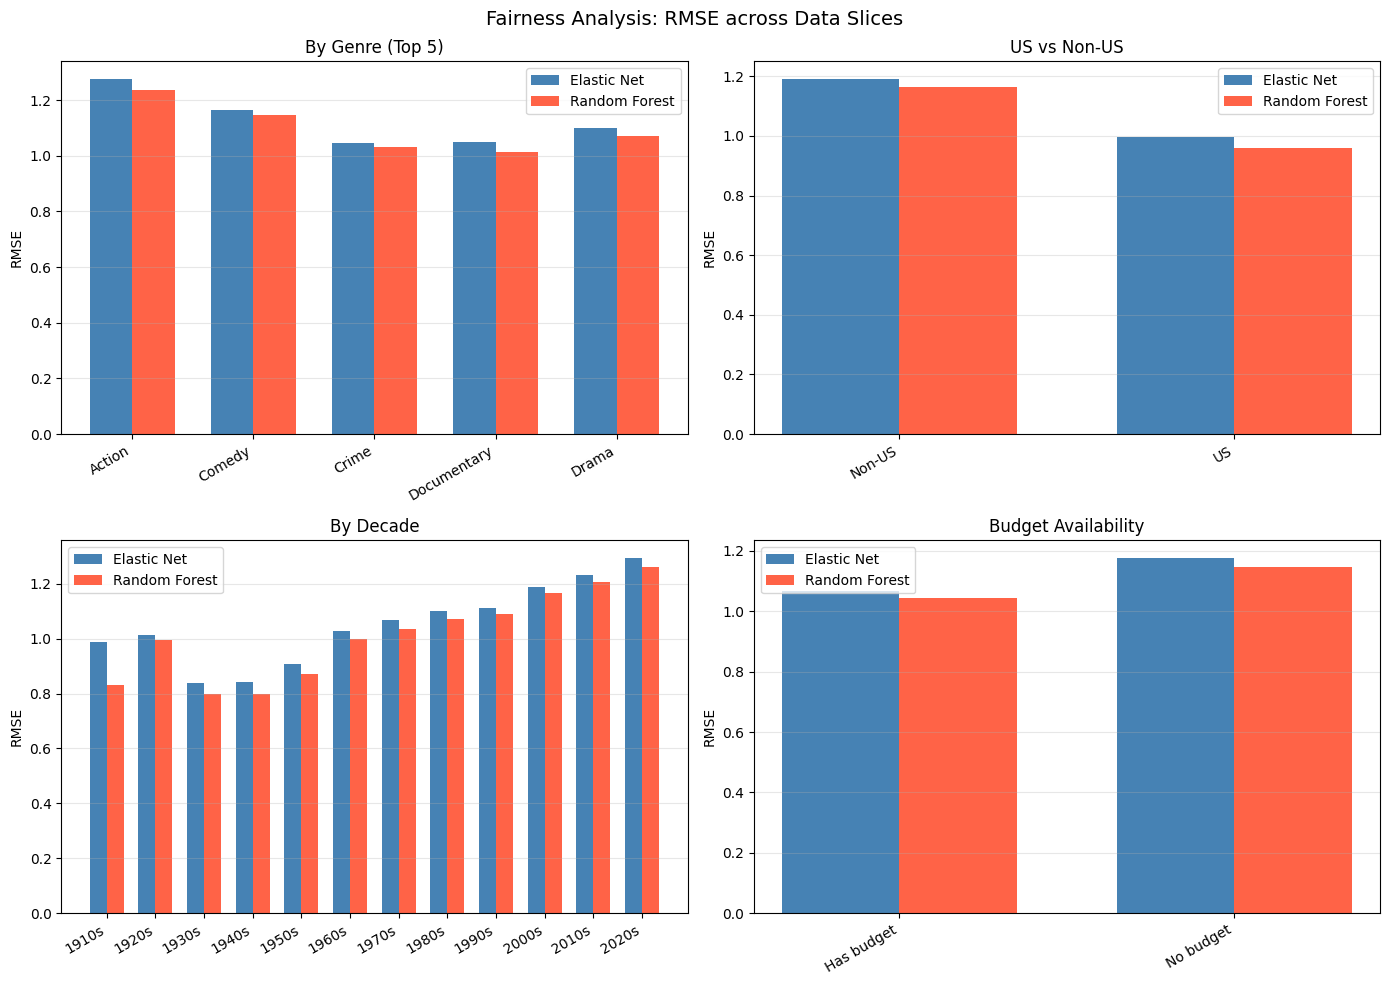

In [61]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Fairness Analysis: RMSE across Data Slices", fontsize=14)

def plot_fairness(ax, fairness_df, title):
    en_data = fairness_df[fairness_df["Model"] == "Elastic Net"].set_index("Slice")["RMSE"]
    rf_data = fairness_df[fairness_df["Model"] == "Random Forest"].set_index("Slice")["RMSE"]

    x = np.arange(len(en_data))
    width = 0.35

    ax.bar(x - width / 2, en_data.values, width, label="Elastic Net",   color="steelblue")
    ax.bar(x + width / 2, rf_data.values, width, label="Random Forest", color="tomato")

    ax.set_xticks(x)
    ax.set_xticklabels(en_data.index, rotation=30, ha="right")
    ax.set_ylabel("RMSE")
    ax.set_title(title)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plot_fairness(axes[0, 0], genre_fairness,  "By Genre (Top 5)")
plot_fairness(axes[0, 1], us_fairness,     "US vs Non-US")
plot_fairness(axes[1, 0], decade_fairness, "By Decade")
plot_fairness(axes[1, 1], budget_fairness, "Budget Availability")

plt.tight_layout()
plt.savefig("fairness_analysis.png", dpi=120, bbox_inches="tight")
plt.show()